In [1]:
from getpass import getuser # Libaray to copy things
from tempfile import NamedTemporaryFile, TemporaryDirectory 

import dask

from dask.distributed import Client
import multiprocessing

ncpu = multiprocessing.cpu_count()
threads = 8
nworker = ncpu // threads
print(
    f"Number of CPUs: {ncpu}, number of threads: {threads}, number of workers: {nworker}"
)
client = Client(
    processes=True, threads_per_worker=threads, n_workers=nworker, memory_limit="100GB"
)
client 

# calculation
#import metpy.calc as mpcalc

# scipy
from scipy import stats
from scipy.ndimage import measurements
from scipy import ndimage
from scipy.optimize import curve_fit

# for plot
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# basic
from pathlib import Path # Object oriented libary to deal with paths
from dask.utils import format_bytes
from distributed import Client, progress, wait # Libaray to orchestrate distributed resources
import netCDF4 as nc
import numpy as np # Pythons standard array library
import xarray as xr # Libary to work with labeled n-dimensional data

# dask
import dask # Distributed data libary
import dask.distributed
import multiprocessing
from subprocess import run, PIPE
import warnings
warnings.filterwarnings(action='ignore')
import pandas as pd
dask.config.config.get('distributed').get('dashboard').update({'link':'{JUPYTERHUB_SERVICE_PREFIX}/proxy/{port}/status'})

Number of CPUs: 256, number of threads: 8, number of workers: 32


2025-09-17 10:48:50,394 - distributed.diskutils - INFO - Found stale lock file and directory '/home/m/m300948/ICON_AMZDEF/Project2/dask-worker-space/worker-00d8m5ht', purging
2025-09-17 10:48:50,401 - distributed.diskutils - INFO - Found stale lock file and directory '/home/m/m300948/ICON_AMZDEF/Project2/dask-worker-space/worker-299htewd', purging
2025-09-17 10:48:50,409 - distributed.diskutils - INFO - Found stale lock file and directory '/home/m/m300948/ICON_AMZDEF/Project2/dask-worker-space/worker-2uaeu77f', purging
2025-09-17 10:48:50,418 - distributed.diskutils - INFO - Found stale lock file and directory '/home/m/m300948/ICON_AMZDEF/Project2/dask-worker-space/worker-3arcdrk6', purging
2025-09-17 10:48:50,437 - distributed.diskutils - INFO - Found stale lock file and directory '/home/m/m300948/ICON_AMZDEF/Project2/dask-worker-space/worker-4lypnbjw', purging
2025-09-17 10:48:50,449 - distributed.diskutils - INFO - Found stale lock file and directory '/home/m/m300948/ICON_AMZDEF/Pro

In [2]:
import sys
sys.path.append('/home/m/m300948/ICON_AMZDEF')
import Tools

Number of CPUs: 256, number of threads: 8, number of workers: 32


## Load data

In [3]:
path = '/work/uc1275/LukasBrunner/data/4Arim/archive/older'
# Daily maximmum near surface air temper (tasmax)
tasmax_ctl = xr.open_dataset(f'{path}/tasmax_ctl.nc')['tas'].sel(time=slice('2022-01-01','2022-12-31'))
tasmax_def = xr.open_dataset(f'{path}/tasmax_def.nc')['tas'].sel(time=slice('2022-01-01','2022-12-31'))

In [57]:
tasmax_ctl

<xarray.DataArray 'tas' (time: 363, lat: 800, lon: 652)>
[189340800 values with dtype=float32]
Coordinates:
  * lon      (lon) float64 -99.95 -99.75 -99.65 -99.55 ... -20.25 -20.15 -20.05
  * lat      (lat) float64 -59.95 -59.85 -59.75 -59.65 ... 19.75 19.85 19.95
  * time     (time) datetime64[ns] 2022-01-01 2022-01-02 ... 2022-12-30
Attributes:
    standard_name:  tas
    long_name:      temperature in 2m
    units:          K
    param:          0.0.0

In [4]:
# SH
sh_ctl = xr.open_dataset(f'{path}/sh_ctl.nc')['hus'].sel(time=slice('2022-01-01','2022-12-31'))
sh_def = xr.open_dataset(f'{path}/sh_def.nc')['hus'].sel(time=slice('2022-01-01','2022-12-31'))

In [5]:
# 1. Apparent temperature (AT) 
at_ctl = xr.open_dataset(f'{path}/at_ctl.nc')['__xarray_dataarray_variable__'].sel(time=slice('2022-01-01','2022-12-31'))
at_def = xr.open_dataset(f'{path}/at_def.nc')['__xarray_dataarray_variable__'].sel(time=slice('2022-01-01','2022-12-31'))

In [6]:
# 2. NOWW Heat Index (HI)
hi_ctl = xr.open_dataset(f'{path}/hi_ctl.nc')['__xarray_dataarray_variable__'].sel(time=slice('2022-01-01','2022-12-31'))
hi_def = xr.open_dataset(f'{path}/hi_def.nc')['__xarray_dataarray_variable__'].sel(time=slice('2022-01-01','2022-12-31'))

In [7]:
# 3. HUMIDEX
humidex_ctl = xr.open_dataset(f'{path}/humidex_ctl.nc')['__xarray_dataarray_variable__'].sel(time=slice('2022-01-01','2022-12-31'))
humidex_def = xr.open_dataset(f'{path}/humidex_def.nc')['__xarray_dataarray_variable__'].sel(time=slice('2022-01-01','2022-12-31'))

In [8]:
# 4. Simplified WBGT (SWBGT)
swbgt_ctl = xr.open_dataset(f'{path}/swbgt_ctl.nc')['__xarray_dataarray_variable__'].sel(time=slice('2022-01-01','2022-12-31'))
swbgt_def = xr.open_dataset(f'{path}/swbgt_def.nc')['__xarray_dataarray_variable__'].sel(time=slice('2022-01-01','2022-12-31'))

In [9]:
# 5. WBGT
wbgt_ctl = xr.open_dataset(f'{path}/wbgt_ctl.nc')['__xarray_dataarray_variable__'].sel(time=slice('2022-01-01','2022-12-31'))
wbgt_def = xr.open_dataset(f'{path}/wbgt_def.nc')['__xarray_dataarray_variable__'].sel(time=slice('2022-01-01','2022-12-31'))

In [10]:
# 6. WBT
wbt_ctl = xr.open_dataset(f'{path}/wbt_ctl.nc')['__xarray_dataarray_variable__'].sel(time=slice('2022-01-01','2022-12-31'))
wbt_def = xr.open_dataset(f'{path}/wbt_def.nc')['__xarray_dataarray_variable__'].sel(time=slice('2022-01-01','2022-12-31'))

In [11]:
# 7. Universal thermal climate index (UTCI)
utci_ctl = xr.open_dataset(f'{path}/utci_ctl.nc')['__xarray_dataarray_variable__'].sel(time=slice('2022-01-01','2022-12-31'))
utci_def = xr.open_dataset(f'{path}/utci_def.nc')['__xarray_dataarray_variable__'].sel(time=slice('2022-01-01','2022-12-31'))

## Load new calculated HSI

In [3]:
path_ctl = '/scratch/m/m300948/HIS/ctl'
path_def = '/scratch/m/m300948/HIS/def'
# Daily maximmum near surface air temper (tasmax)
hsi_ctl_new = xr.open_mfdataset(f'{path_ctl}/ctl_daily_hsi_*').sel(time=slice('2022-01-01','2022-12-31'))
#tasmax_def = xr.open_dataset(f'{path}/tasmax_def.nc')['tas'].sel(time=slice('2022-01-01','2022-12-31'))

In [4]:
hsi_def_new = xr.open_mfdataset(f'{path_def}/def_daily_hsi_*').sel(time=slice('2022-01-01','2022-12-31'))

In [5]:
tasmax_ctl_new = hsi_ctl_new.tasmax
tasmax_def_new = hsi_def_new.tasmax

In [6]:
at_ctl_new = hsi_ctl_new.apparent_temperature
at_def_new = hsi_def_new.apparent_temperature

In [7]:
hi_ctl_new = hsi_ctl_new.heat_index
hi_def_new = hsi_def_new.heat_index

In [8]:
humidex_ctl_new = hsi_ctl_new.humidex
humidex_def_new = hsi_def_new.humidex

In [9]:
swbgt_ctl_new = hsi_ctl_new.simple_wbgt
swbgt_def_new = hsi_def_new.simple_wbgt

In [10]:
wbgt_ctl_new = hsi_ctl_new.wbgt
wbgt_def_new = hsi_def_new.wbgt

In [11]:
wbt_ctl_new =hsi_ctl_new.wbt
wbt_def_new =hsi_def_new.wbt

In [12]:
utci_ctl_new = hsi_ctl_new.utci
utci_def_new = hsi_def_new.utci

## Load new calculated HSI - dt or dq

In [13]:
path_dt = '/scratch/m/m300948/HIS/onlydt'
path_dq = '/scratch/m/m300948/HIS/onlydq'
# Daily maximmum near surface air temper (tasmax)
hsi_dt_new = xr.open_mfdataset(f'{path_dt}/onlydt_daily_hsi_*').sel(time=slice('2022-01-01','2022-12-31'))
hsi_dq_new = xr.open_mfdataset(f'{path_dq}/onlydq_daily_hsi_*').sel(time=slice('2022-01-01','2022-12-31'))

In [14]:
tasmax_dt_new = hsi_dt_new.tasmax
tasmax_dq_new = hsi_dq_new.tasmax

In [15]:
at_dt_new = hsi_dt_new.apparent_temperature
at_dq_new = hsi_dq_new.apparent_temperature

In [16]:
hi_dt_new = hsi_dt_new.heat_index
hi_dq_new = hsi_dq_new.heat_index

In [17]:
humidex_dt_new = hsi_dt_new.humidex
humidex_dq_new = hsi_dq_new.humidex

In [18]:
swbgt_dt_new = hsi_dt_new.simple_wbgt
swbgt_dq_new = hsi_dq_new.simple_wbgt

In [19]:
wbgt_dt_new = hsi_dt_new.wbgt
wbgt_dq_new = hsi_dq_new.wbgt

In [20]:
wbt_dt_new =hsi_dt_new.wbt
wbt_dq_new =hsi_dq_new.wbt

In [21]:
utci_dt_new = hsi_dt_new.utci
utci_dq_new = hsi_dq_new.utci

## Masking

### old

In [22]:
dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
AMZ_BD = dset_bd.AMAZON_BIOMES

In [ ]:
ABinterp_biome = AMZ_BD.interp(latitude=tasmax_ctl.lat, longitude=tasmax_ctl.lon)

In [24]:
# tasmax
tasmax_ctl_mask = tasmax_ctl.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
tasmax_def_mask = tasmax_def.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [25]:
at_ctl_mask = at_ctl.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
at_def_mask = at_def.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [26]:
hi_ctl_mask = hi_ctl.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
hi_def_mask = hi_def.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [27]:
humidex_ctl_mask = humidex_ctl.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
humidex_def_mask = humidex_def.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [28]:
swbgt_ctl_mask = swbgt_ctl.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
swbgt_def_mask = swbgt_def.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [29]:
wbgt_ctl_mask = wbgt_ctl.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
wbgt_def_mask = wbgt_def.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [30]:
wbt_ctl_mask = wbt_ctl.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
wbt_def_mask = wbt_def.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [31]:
utci_ctl_mask = utci_ctl.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
utci_def_mask = utci_def.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

### New

In [24]:
ABinterp_biome_new = AMZ_BD.interp(latitude=tasmax_ctl_new.lat, longitude=tasmax_ctl_new.lon)

In [25]:
# tasmax
tasmax_ctl_new_mask = tasmax_ctl_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
tasmax_def_new_mask = tasmax_def_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [26]:
at_ctl_new_mask = at_ctl_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
at_def_new_mask = at_def_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [27]:
hi_ctl_new_mask = hi_ctl_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
hi_def_new_mask = hi_def_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [28]:
humidex_ctl_new_mask = humidex_ctl_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
humidex_def_new_mask = humidex_def_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [29]:
swbgt_ctl_new_mask = swbgt_ctl_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
swbgt_def_new_mask = swbgt_def_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [30]:
wbgt_ctl_new_mask = wbgt_ctl_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
wbgt_def_new_mask = wbgt_def_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [31]:
wbt_ctl_new_mask = wbt_ctl_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
wbt_def_new_mask = wbt_def_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [32]:
utci_ctl_new_mask = utci_ctl_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
utci_def_new_mask = utci_def_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

### New - dt and dq

In [33]:
ABinterp_biome_new = AMZ_BD.interp(latitude=tasmax_ctl_new.lat, longitude=tasmax_ctl_new.lon)

In [34]:
# tasmax
tasmax_dt_new_mask = tasmax_dt_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
tasmax_dq_new_mask = tasmax_dq_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [35]:
at_dt_new_mask = at_dt_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
at_dq_new_mask = at_dq_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [36]:
hi_dt_new_mask = hi_dt_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
hi_dq_new_mask = hi_dq_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [37]:
humidex_dt_new_mask = humidex_dt_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
humidex_dq_new_mask = humidex_dq_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [38]:
swbgt_dt_new_mask = swbgt_dt_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
swbgt_dq_new_mask = swbgt_dq_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [39]:
wbgt_dt_new_mask = wbgt_dt_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
wbgt_dq_new_mask = wbgt_dq_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [40]:
wbt_dt_new_mask = wbt_dt_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
wbt_dq_new_mask = wbt_dq_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [41]:
utci_dt_new_mask = utci_dt_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
utci_dq_new_mask = utci_dq_new.where(ABinterp_biome_new == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

## Flattens

In [41]:
xarray_names = ['tasmax_ctl_mask','tasmax_def_mask']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [42]:
xarray_names = ['at_ctl_mask','at_def_mask']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [43]:
xarray_names = ['hi_ctl_mask','hi_def_mask']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [44]:
xarray_names = ['humidex_ctl_mask','humidex_def_mask']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [45]:
xarray_names = ['swbgt_ctl_mask','swbgt_def_mask']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [46]:
xarray_names = ['wbgt_ctl_mask','wbgt_def_mask']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [47]:
xarray_names = ['wbt_ctl_mask','wbt_def_mask']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [48]:
xarray_names = ['utci_ctl_mask','utci_def_mask']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

## Flattens - new

In [42]:
xarray_names = ['tasmax_ctl_new_mask','tasmax_def_new_mask']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.isel(height_2=0).values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

2025-09-17 10:57:13,698 - distributed.nanny - WARNING - Restarting worker


In [43]:
xarray_names = ['at_ctl_new_mask','at_def_new_mask']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [44]:
xarray_names = ['hi_ctl_new_mask','hi_def_new_mask']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [45]:
xarray_names = ['humidex_ctl_new_mask','humidex_def_new_mask']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [46]:
xarray_names = ['swbgt_ctl_new_mask','swbgt_def_new_mask']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [47]:
xarray_names = ['wbgt_ctl_new_mask','wbgt_def_new_mask']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [48]:
xarray_names = ['wbt_ctl_new_mask','wbt_def_new_mask']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [49]:
xarray_names = ['utci_ctl_new_mask','utci_def_new_mask']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

2025-09-17 10:57:43,186 - distributed.worker - ERROR - Worker stream died during communication: tcp://127.0.0.1:40825
Traceback (most recent call last):
  File "/home/m/m300948/.conda/envs/JUPYTER_MODULE/lib/python3.9/site-packages/tornado/iostream.py", line 867, in _read_to_buffer
    bytes_read = self.read_from_fd(buf)
  File "/home/m/m300948/.conda/envs/JUPYTER_MODULE/lib/python3.9/site-packages/tornado/iostream.py", line 1140, in read_from_fd
    return self.socket.recv_into(buf, len(buf))
ConnectionResetError: [Errno 104] Connection reset by peer

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/m/m300948/.conda/envs/JUPYTER_MODULE/lib/python3.9/site-packages/distributed/worker.py", line 2952, in gather_dep
    response = await get_data_from_worker(
  File "/home/m/m300948/.conda/envs/JUPYTER_MODULE/lib/python3.9/site-packages/distributed/worker.py", line 4160, in get_data_from_worker
    return await retry_oper

## Flattens - dt and dq

In [50]:
xarray_names = ['tasmax_dt_new_mask','tasmax_dq_new_mask']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.isel(height_2=0).values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [51]:
xarray_names = ['at_dt_new_mask','at_dq_new_mask']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [52]:
xarray_names = ['hi_dt_new_mask','hi_dq_new_mask']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [53]:
xarray_names = ['humidex_dt_new_mask','humidex_dq_new_mask']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [54]:
xarray_names = ['swbgt_dt_new_mask','swbgt_dq_new_mask']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [55]:
xarray_names = ['wbgt_dt_new_mask','wbgt_dq_new_mask']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [56]:
xarray_names = ['wbt_dt_new_mask','wbt_dq_new_mask']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [57]:
xarray_names = ['utci_dt_new_mask','utci_dq_new_mask']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

## Count the numbers of days above the level3

In [58]:
at = 35
hi = 41
hu = 45
twbg = 32
twbgs = 32
utci = 38

# Box and Whisker Plot

_old_

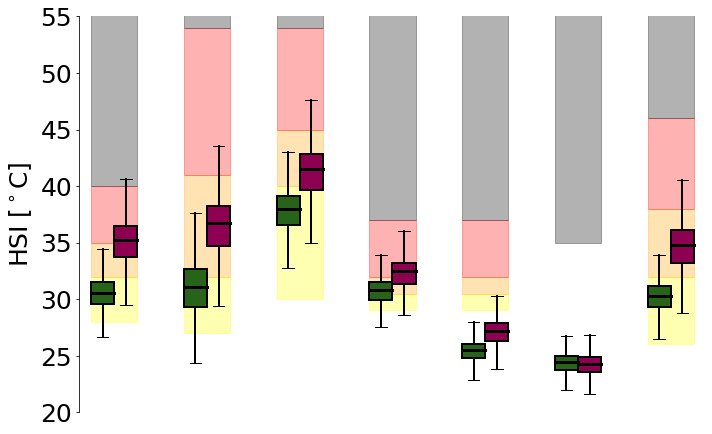

In [58]:
import matplotlib.cm
import matplotlib.pyplot as plt

# Define the data to plot
data_to_plot = [at_ctl_mask_f, at_def_mask_f, hi_ctl_mask_f, hi_def_mask_f, humidex_ctl_mask_f, humidex_def_mask_f, swbgt_ctl_mask_f, swbgt_def_mask_f, wbgt_ctl_mask_f, wbgt_def_mask_f, wbt_ctl_mask_f, wbt_def_mask_f, utci_ctl_mask_f, utci_def_mask_f]

# Define positions with small gaps between pairs
positions = [1, 1.5, 3, 3.5, 5, 5.5, 7, 7.5, 9, 9.5, 11, 11.5, 13, 13.5]
positions_color = [1.25, 3.25, 5.25, 7.25, 9.25, 11.25, 13.25]
# Define ranges and corresponding colors for the background
background_ranges_at = [
    (28, 32, 'yellow'),     # Below 28 to 32
    (32, 35, 'orange'),     # 32 to 35
    (35, 40, 'red'),        # 35 to 40
    (40, 60, 'black')       # Above 40
]
background_ranges_hi = [
    (27, 32, 'yellow'),     # Below 28 to 32
    (32, 41, 'orange'),     # 32 to 35
    (41, 54, 'red'),        # 35 to 40
    (54, 60, 'black')       # Above 40
]
background_ranges_humidex = [
    (30, 40, 'yellow'),     # Below 28 to 32
    (40, 45, 'orange'),     # 32 to 35
    (45, 54, 'red'),        # 35 to 40
    (54, 60, 'black')       # Above 40
]
background_ranges_swbgt = [
    (29, 30.5, 'yellow'),     # Below 28 to 32
    (30.5, 32, 'orange'),     # 32 to 35
    (32, 37, 'red'),        # 35 to 40
    (37, 60, 'black')       # Above 40
]
background_ranges_wbgt = [
    (29, 30.5, 'yellow'),     # Below 28 to 32
    (30.5, 32, 'orange'),     # 32 to 35
    (32, 37, 'red'),        # 35 to 40
    (37, 60, 'black')       # Above 40
]
background_ranges_wbt = [
    (35, 60, 'black')       # Above 40
]
background_ranges_utci = [
    (26, 32, 'yellow'),     # Below 28 to 32
    (32, 38, 'orange'),     # 32 to 35
    (38, 46, 'red'),        # 35 to 40
    (46, 60, 'black')       # Above 40
]

# Plot the box-and-whisker plot
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_alpha(0.0)

boxplots = ax.boxplot(
    data_to_plot, 
    positions=positions, 
    vert=True, 
    patch_artist=True, 
    showmeans=False, 
    showfliers=False,
    boxprops={'color': 'black', 'linewidth': 2},
    whiskerprops={'color': 'black', 'linewidth': 2},
    medianprops={'color': 'black', 'linewidth': 3}
)

# Apply background coloring for each box plot column
#for i, pos in enumerate(positions_color):
#    for ymin, ymax, color in background_ranges:
#        ax.axhspan(ymin, ymax, xmin=(pos - 0.25) / 10, xmax=(pos + 0.25) / 10, color=color, alpha=0.3)
for ymin, ymax, color in background_ranges_at:
    ax.axhspan(ymin, ymax, xmin=(positions[0] - 0.75) / 13.5 , xmax=(positions[0] + 0.25) / 13.5, color=color, alpha=0.3)
for ymin, ymax, color in background_ranges_hi:
    ax.axhspan(ymin, ymax, xmin=(positions[2] - 0.75) / 13.5, xmax=(positions[2] + 0.25) / 13.5, color=color, alpha=0.3)
for ymin, ymax, color in background_ranges_humidex:
    ax.axhspan(ymin, ymax, xmin=(positions[4] - 0.75) / 13.5, xmax=(positions[4] + 0.25) / 13.5, color=color, alpha=0.3)
for ymin, ymax, color in background_ranges_swbgt:    
    ax.axhspan(ymin, ymax, xmin=(positions[6] - 0.75) / 13.5, xmax=(positions[6] + 0.25) / 13.5, color=color, alpha=0.3)
for ymin, ymax, color in background_ranges_wbgt:    
    ax.axhspan(ymin, ymax, xmin=(positions[8] - 0.75) / 13.5, xmax=(positions[8] + 0.25) / 13.5, color=color, alpha=0.3)
for ymin, ymax, color in background_ranges_wbt:    
    ax.axhspan(ymin, ymax, xmin=(positions[10] - 0.75) / 13.5, xmax=(positions[10] + 0.25) / 13.5, color=color, alpha=0.3)
for ymin, ymax, color in background_ranges_utci:
    ax.axhspan(ymin, ymax, xmin=(positions[12] - 0.75) / 13.5, xmax=(positions[12] + 0.25) / 13.5, color=color, alpha=0.3)

# Change the color of each box
cmap = matplotlib.cm.get_cmap('PiYG')
left = cmap(0.0)
right = cmap(1.0)
colors = [right, left, right, left, right, left, right, left, right, left, right, left, right, left]
for box, color in zip(boxplots['boxes'], colors):
    box.set_facecolor(color)

# Customize the plot
ax.tick_params(axis='y', labelsize=25, colors='black')
ax.tick_params(axis='x', bottom=False, labelbottom=False)

# Y-axis label
ax.set_ylabel(r'HSI [$^\circ$C]', fontsize=25, color='black', rotation=90, labelpad=20, va='center')

# Remove grid and spines
ax.grid(False)
for spine in ['top', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)

# Adjust left spine color
ax.spines['left'].set_color('black')
ax.set_ylim(20, 55)
# Show the plot
plt.tight_layout()
plt.show()


In [62]:
print(at_ctl_new_mask_f.mean())
print(at_def_new_mask_f.mean()) 

print(hi_ctl_new_mask_f.mean())
print(hi_def_new_mask_f.mean())

print(humidex_ctl_new_mask_f.mean())
print(humidex_def_new_mask_f.mean()) 

print(swbgt_ctl_new_mask_f.mean())
print(swbgt_def_new_mask_f.mean())

print(wbgt_ctl_new_mask_f.mean())
print(wbgt_def_new_mask_f.mean())

print(wbt_ctl_new_mask_f.mean())
print(wbt_def_new_mask_f.mean())

print(utci_ctl_new_mask_f.mean())
print(utci_def_new_mask_f.mean())

29.950758
34.335854
30.300486
35.44318
36.604774
39.977318
29.86435
31.432964
24.714708162077834
26.305078578955857
23.40219743097928
23.17997268978951
29.605782
34.005188


_new_

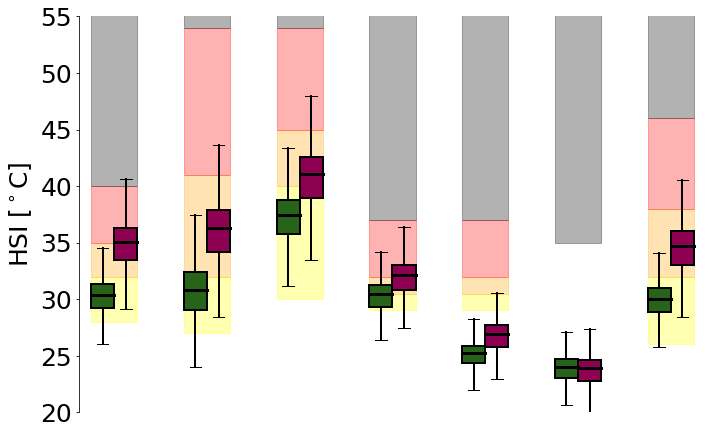

In [59]:
import matplotlib.cm
import matplotlib.pyplot as plt

# Define the data to plot
data_to_plot = [at_ctl_new_mask_f, at_def_new_mask_f, hi_ctl_new_mask_f, hi_def_new_mask_f, humidex_ctl_new_mask_f, humidex_def_new_mask_f, 
                swbgt_ctl_new_mask_f, swbgt_def_new_mask_f, wbgt_ctl_new_mask_f, wbgt_def_new_mask_f, wbt_ctl_new_mask_f, wbt_def_new_mask_f, utci_ctl_new_mask_f, utci_def_new_mask_f]

# Define positions with small gaps between pairs
positions = [1, 1.5, 3, 3.5, 5, 5.5, 7, 7.5, 9, 9.5, 11, 11.5, 13, 13.5]
positions_color = [1.25, 3.25, 5.25, 7.25, 9.25, 11.25, 13.25]
# Define ranges and corresponding colors for the background
background_ranges_at = [
    (28, 32, 'yellow'),     # Below 28 to 32
    (32, 35, 'orange'),     # 32 to 35
    (35, 40, 'red'),        # 35 to 40
    (40, 60, 'black')       # Above 40
]
background_ranges_hi = [
    (27, 32, 'yellow'),     # Below 28 to 32
    (32, 41, 'orange'),     # 32 to 35
    (41, 54, 'red'),        # 35 to 40
    (54, 60, 'black')       # Above 40
]
background_ranges_humidex = [
    (30, 40, 'yellow'),     # Below 28 to 32
    (40, 45, 'orange'),     # 32 to 35
    (45, 54, 'red'),        # 35 to 40
    (54, 60, 'black')       # Above 40
]
background_ranges_swbgt = [
    (29, 30.5, 'yellow'),     # Below 28 to 32
    (30.5, 32, 'orange'),     # 32 to 35
    (32, 37, 'red'),        # 35 to 40
    (37, 60, 'black')       # Above 40
]
background_ranges_wbgt = [
    (29, 30.5, 'yellow'),     # Below 28 to 32
    (30.5, 32, 'orange'),     # 32 to 35
    (32, 37, 'red'),        # 35 to 40
    (37, 60, 'black')       # Above 40
]
background_ranges_wbt = [
    (35, 60, 'black')       # Above 40
]
background_ranges_utci = [
    (26, 32, 'yellow'),     # Below 28 to 32
    (32, 38, 'orange'),     # 32 to 35
    (38, 46, 'red'),        # 35 to 40
    (46, 60, 'black')       # Above 40
]

# Plot the box-and-whisker plot
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_alpha(0.0)

boxplots = ax.boxplot(
    data_to_plot, 
    positions=positions, 
    vert=True, 
    patch_artist=True, 
    showmeans=False, 
    showfliers=False,
    boxprops={'color': 'black', 'linewidth': 2},
    whiskerprops={'color': 'black', 'linewidth': 2},
    medianprops={'color': 'black', 'linewidth': 3}
)

# Apply background coloring for each box plot column
#for i, pos in enumerate(positions_color):
#    for ymin, ymax, color in background_ranges:
#        ax.axhspan(ymin, ymax, xmin=(pos - 0.25) / 10, xmax=(pos + 0.25) / 10, color=color, alpha=0.3)
for ymin, ymax, color in background_ranges_at:
    ax.axhspan(ymin, ymax, xmin=(positions[0] - 0.75) / 13.5 , xmax=(positions[0] + 0.25) / 13.5, color=color, alpha=0.3)
for ymin, ymax, color in background_ranges_hi:
    ax.axhspan(ymin, ymax, xmin=(positions[2] - 0.75) / 13.5, xmax=(positions[2] + 0.25) / 13.5, color=color, alpha=0.3)
for ymin, ymax, color in background_ranges_humidex:
    ax.axhspan(ymin, ymax, xmin=(positions[4] - 0.75) / 13.5, xmax=(positions[4] + 0.25) / 13.5, color=color, alpha=0.3)
for ymin, ymax, color in background_ranges_swbgt:    
    ax.axhspan(ymin, ymax, xmin=(positions[6] - 0.75) / 13.5, xmax=(positions[6] + 0.25) / 13.5, color=color, alpha=0.3)
for ymin, ymax, color in background_ranges_wbgt:    
    ax.axhspan(ymin, ymax, xmin=(positions[8] - 0.75) / 13.5, xmax=(positions[8] + 0.25) / 13.5, color=color, alpha=0.3)
for ymin, ymax, color in background_ranges_wbt:    
    ax.axhspan(ymin, ymax, xmin=(positions[10] - 0.75) / 13.5, xmax=(positions[10] + 0.25) / 13.5, color=color, alpha=0.3)
for ymin, ymax, color in background_ranges_utci:
    ax.axhspan(ymin, ymax, xmin=(positions[12] - 0.75) / 13.5, xmax=(positions[12] + 0.25) / 13.5, color=color, alpha=0.3)

# Change the color of each box
cmap = matplotlib.cm.get_cmap('PiYG')
left = cmap(0.0)
right = cmap(1.0)
colors = [right, left, right, left, right, left, right, left, right, left, right, left, right, left]
for box, color in zip(boxplots['boxes'], colors):
    box.set_facecolor(color)

# Customize the plot
ax.tick_params(axis='y', labelsize=25, colors='black')
ax.tick_params(axis='x', bottom=False, labelbottom=False)

# Y-axis label
ax.set_ylabel(r'HSI [$^\circ$C]', fontsize=25, color='black', rotation=90, labelpad=20, va='center')

# Remove grid and spines
ax.grid(False)
for spine in ['top', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)

# Adjust left spine color
ax.spines['left'].set_color('black')
ax.set_ylim(20, 55)
# Show the plot
plt.tight_layout()
plt.show()


_dt_

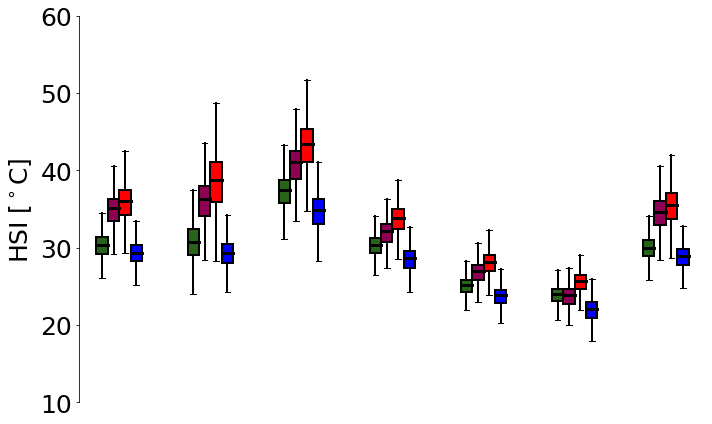

In [60]:
import matplotlib.cm
import matplotlib.pyplot as plt

# dqine the data to plot
data_to_plot = [at_ctl_new_mask_f, at_def_new_mask_f, at_dt_new_mask_f, at_dq_new_mask_f, 
                hi_ctl_new_mask_f, hi_def_new_mask_f, hi_dt_new_mask_f, hi_dq_new_mask_f, 
                humidex_ctl_new_mask_f, humidex_def_new_mask_f, humidex_dt_new_mask_f, humidex_dq_new_mask_f, 
                swbgt_ctl_new_mask_f, swbgt_def_new_mask_f, swbgt_dt_new_mask_f, swbgt_dq_new_mask_f, 
                wbgt_ctl_new_mask_f, wbgt_def_new_mask_f, wbgt_dt_new_mask_f, wbgt_dq_new_mask_f, 
                wbt_ctl_new_mask_f, wbt_def_new_mask_f, wbt_dt_new_mask_f, wbt_dq_new_mask_f, 
                utci_ctl_new_mask_f, utci_def_new_mask_f, utci_dt_new_mask_f, utci_dq_new_mask_f]

# dqine positions with small gaps between pairs
positions = [1, 1.25, 1.5, 1.75, 
             3, 3.25, 3.5, 3.75,
             5, 5.25, 5.5, 5.75,
             7, 7.25, 7.5, 7.75,
             9, 9.25, 9.5, 9.75,
             11, 11.25, 11.5, 11.75,
             13, 13.25, 13.5, 13.75]
positions_color = [1.25, 3.25, 5.25, 7.25, 9.25, 11.25, 13.25]

# Plot the box-and-whisker plot
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_alpha(0.0)

boxplots = ax.boxplot(
    data_to_plot, 
    positions=positions, 
    vert=True, 
    patch_artist=True, 
    showmeans=False, 
    showfliers=False,
    widths=0.25,
    boxprops={'color': 'black', 'linewidth': 2},
    whiskerprops={'color': 'black', 'linewidth': 2},
    medianprops={'color': 'black', 'linewidth': 3}
)

# Change the color of each box
cmap = matplotlib.cm.get_cmap('PiYG')
left = cmap(0.0)
right = cmap(1.0)
colors = [right, left, 'red', 'blue', 
          right, left, 'red', 'blue', 
          right, left, 'red', 'blue', 
          right, left, 'red', 'blue', 
          right, left, 'red', 'blue', 
          right, left, 'red', 'blue', 
          right, left, 'red', 'blue']
for box, color in zip(boxplots['boxes'], colors):
    box.set_facecolor(color)

# Customize the plot
ax.tick_params(axis='y', labelsize=25, colors='black')
ax.tick_params(axis='x', bottom=False, labelbottom=False)

# Y-axis label
ax.set_ylabel(r'HSI [$^\circ$C]', fontsize=25, color='black', rotation=90, labelpad=20, va='center')

# Remove grid and spines
ax.grid(False)
for spine in ['top', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)

# Adjust left spine color
ax.spines['left'].set_color('black')
ax.set_ylim(10, 60)
# Show the plot
plt.tight_layout()
plt.show()


In [61]:
print(at_dt_new_mask_f.mean(), at_dq_new_mask_f.mean())

print(hi_dt_new_mask_f.mean(),hi_dq_new_mask_f.mean())

print(humidex_dt_new_mask_f.mean(), humidex_dq_new_mask_f.mean())

print(swbgt_dt_new_mask_f.mean(), swbgt_dq_new_mask_f.mean())

print(wbgt_dt_new_mask_f.mean(), wbgt_dq_new_mask_f.mean())

print(wbt_dt_new_mask_f.mean(), wbt_dq_new_mask_f.mean())

print(utci_dt_new_mask_f.mean(), utci_dq_new_mask_f.mean())

35.339474 28.976564
37.900143 28.91656
42.462097 34.197796
33.1854 28.167265
27.620491928923222 23.387864151840596
25.0430379766865 21.523900762224994
34.859585 28.576982


In [63]:
hsi = np.array([['name','ctl','def','dt','dq'],
               ['at', 29.95, 34.34, 35.34, 29.00], # at
    ['hi', 30.30, 35.44, 37.90, 28.92], # hi
['humidex', 36.60, 40.00, 42.46, 34.20], # humidex
['swbgt', 29.86, 31.43, 33.19, 28.17],  # swbgt
['wbgt', 24.71, 26.31, 27.62, 23.39], # wbgt
['wbt', 23.40, 23.18, 25.04, 21.52],  # wbt
['utci', 29.60, 34.01, 34.86, 28.58] # utci 
                ])

In [64]:
hsi_pd = pd.DataFrame(data = hsi[1:, 1:],
             index= hsi[1:,0],
             columns=hsi[0,1:])

In [65]:
hsi_pd

,ctl,def,dt,dq
at,29.95,34.34,35.34,29.0
hi,30.3,35.44,37.9,28.92
humidex,36.6,40.0,42.46,34.2
swbgt,29.86,31.43,33.19,28.17
wbgt,24.71,26.31,27.62,23.39
wbt,23.4,23.18,25.04,21.52
utci,29.6,34.01,34.86,28.58


In [85]:
import pandas as pd

hsi_data = {
    "ctl":   [29.95, 30.30, 36.60, 29.86, 24.71, 23.40, 29.60],
    "def":   [34.36-29.95, 35.44-30.30, 40.00-36.60, 31.43-29.86, 26.31-24.71, 23.18-23.40, 34.01-29.60],
    "dt":    [35.34-29.95, 37.90-30.30, 42.46-36.60, 33.19-29.86, 27.62-24.71, 25.04-23.40, 34.86-29.60],
    "dq":    [29.00-29.95, 28.92-30.30, 34.20-36.60, 28.17-29.86, 23.39-24.71, 21.52-23.40, 28.58-29.60],
}

index = ["at", "hi", "humidex", "swbgt", "wbgt", "wbt", "utci"]

hsi_pd = pd.DataFrame(hsi_data, index=index)
print(hsi_pd)


           ctl   def    dt    dq
at       29.95  4.41  5.39 -0.95
hi       30.30  5.14  7.60 -1.38
humidex  36.60  3.40  5.86 -2.40
swbgt    29.86  1.57  3.33 -1.69
wbgt     24.71  1.60  2.91 -1.32
wbt      23.40 -0.22  1.64 -1.88
utci     29.60  4.41  5.26 -1.02


In [88]:
hsi_pd['ratio_dt'] = hsi_pd['dt'] / hsi_pd['def'] * 100
hsi_pd['ratio_dq'] = hsi_pd['dq'] / hsi_pd['def'] * 100

In [89]:
hsi_pd

,ctl,def,dt,dq,ratio_dt,ratio_dq
at,29.95,4.41,5.39,-0.95,122.222222,-21.541950
hi,30.30,5.14,7.60,-1.38,147.859922,-26.848249
humidex,36.60,3.40,5.86,-2.40,172.352941,-70.588235
swbgt,29.86,1.57,3.33,-1.69,212.101911,-107.643312
wbgt,24.71,1.60,2.91,-1.32,181.875000,-82.500000
wbt,23.40,-0.22,1.64,-1.88,-745.454545,854.545455
utci,29.60,4.41,5.26,-1.02,119.274376,-23.129252
